<a href="https://colab.research.google.com/github/Tarakk/CML7211_ML4Chem/blob/main/GNN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
!pip install pytorch-lightning wandb rdkit ogb
!pip install torch_geometric
!pip install pubchempy
!pip install -U scikit-learn

In [43]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/My Drive/courses_@IITD/ML4Chem_CML7211/solubility_data.csv")
df.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1
5,benzothiazole,-2.733,2,135.191,0,2,0,12.89,-1.50,c2ccc1scnc1c2
6,"2,2,4,6,6'-PCB",-6.545,1,326.437,0,2,1,0.00,-7.32,Clc1cc(Cl)c(c(Cl)c1)c2c(Cl)cccc2Cl
7,Estradiol,-4.138,1,272.388,2,4,0,40.46,-5.03,CC12CCC3C(CCc4cc(O)ccc34)C2CCC1O
8,Dieldrin,-4.533,1,380.913,0,5,0,12.53,-6.29,ClC4=C(Cl)C5(Cl)C3C1CC(C2OC12)C3C4(Cl)C5(Cl)Cl
9,Rotenone,-5.246,1,394.423,0,5,3,63.22,-4.42,COc5cc4OCC3Oc2c1CC(Oc1ccc2C(=O)C3c4cc5OC)C(C)=C


In [44]:
smiles_list = df['smiles']
targets = df['measured log solubility in mols per litre']

In [45]:
from rdkit import Chem

valid_smiles = []
valid_targets = []

for smi, y in zip(smiles_list, targets):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        valid_smiles.append(smi)
        valid_targets.append(y)

print("Valid molecules:", len(valid_smiles))

Valid molecules: 1128


In [46]:
import torch
from torch_geometric.data import Data

def mol_to_graph(smiles, y):
    mol = Chem.MolFromSmiles(smiles)

    # node features
    atom_fvs = []
    for atom in mol.GetAtoms():
        atom_fvs.append([
            atom.GetAtomicNum(),
            atom.GetDegree(),
            atom.GetFormalCharge(),
            int(atom.GetHybridization()),
            atom.GetNumImplicitHs(),
            int(atom.GetIsAromatic())
        ])

    # edges
    edge_index = []
    bond_fvs = []

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        edge_index += [[i, j], [j, i]]

        bf = [
            bond.GetBondTypeAsDouble(),
            int(bond.GetIsConjugated()),
            int(bond.IsInRing())
        ]

        bond_fvs += [bf, bf]

    # convert
    x = torch.tensor(atom_fvs, dtype=torch.float)

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(bond_fvs, dtype=torch.float)

    y = torch.tensor([[y]], dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    data.smiles = smiles

    return data

In [47]:
dataset = [mol_to_graph(smi, y) for smi, y in zip(valid_smiles, valid_targets)]

In [48]:
def normalize_dataset(dataset):
    y_all = torch.cat([data.y for data in dataset], dim=0)
    mean, std = y_all.mean(), y_all.std()

    for data in dataset:
        data.y = (data.y - mean) / std

    return dataset, mean.item(), std.item()

In [49]:
dataset, mean, std = normalize_dataset(dataset)

In [50]:
import random

#dataset = dataset.shuffle()
random.shuffle(dataset)

n = len(dataset)
train_dataset = dataset[:int(0.7*n)]
val_dataset   = dataset[int(0.7*n):int(0.8*n)]
test_dataset  = dataset[int(0.8*n):]

In [51]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

##MPNN

Graph: $$G=(V,E)$$
Node (atom) features: $$h_i^{(t)} \in R^{F_{in}}$$
Edge (bond) features: $$e_{ij}^{(t)} \in R^D$$
where $F_{in} = \text{in_channels & D}  = \text{edge_dim}$ <br>

Each edge feature goes through a neural network:
$$W_{ij}​ = \phi(e_{ij}​)$$
where $\phi$ is the nn1/nn2

Output shape:  $W_{ij}  \in \mathbb{R}^{F_{in} \times F_{out}}$

Neural net outputs a flattened vector: $\phi(e_{ij}) \in \mathbb{R}^{F_{in} . F_{out}}$

Each neighbor j sends a message to node i: $m_{ij}​=W_{ij}​⋅h_j^{(t)}​$

Node i collects messages from neighbors: $m_i​ = \frac{1}{|N(i)|}\sum_{j∈N(i)}m_{ij}​$

Final node representation: $h_i^{(t+1)}​ = \sigma(m_i​+b)$

where $\sigma$ = ReLU

### Putting everything together:

$h_i^{(t+1)}​=\sigma \left ( \sum_{​j∈N(i)}\phi(e_{ij}​)⋅h_j^{(t)} \right )$​



## Workflow
Node features (x) <br>
   ↓

NNConv (edge-conditioned) <br>
      ↓
      
ReLU <br>
      ↓
      
NNConv <br>
         ↓
         
ReLU <br>
        ↓
          
Pooling (mean) <br>
          ↓
        
Linear <br>
          ↓
        
Predicted logS

In [52]:
import torch.nn as nn
from torch_geometric.nn import NNConv, global_mean_pool

class MPNNModel(nn.Module):
    def __init__(self, in_channels, edge_dim, hidden_dim=64):
        super().__init__()

        # in_channels --> hidden_dim
        nn1 = nn.Sequential(
            nn.Linear(edge_dim, 128),
            nn.ReLU(),
            nn.Linear(128, in_channels * hidden_dim) # hidden_dim: learned chemical understanding
        )

        # hidden_dim --> hidden_dim
        nn2 = nn.Sequential(
            nn.Linear(edge_dim, 128),
            nn.ReLU(),
            nn.Linear(128, hidden_dim * hidden_dim)
        )

        self.conv1 = NNConv(in_channels, hidden_dim, nn1, aggr='mean')
        self.conv2 = NNConv(hidden_dim, hidden_dim, nn2, aggr='mean')

        self.lin = nn.Linear(hidden_dim, 1) # embedding --> solubility

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.conv1(x, edge_index, edge_attr).relu()
        x = self.conv2(x, edge_index, edge_attr).relu()

        x = global_mean_pool(x, batch) # global pooling h_mol​=mean(h1​,h2​,...,hN​)

        return self.lin(x) # molecule embedding to logS

## Initialize

In [53]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = MPNNModel(
    in_channels=train_dataset[0].num_node_features,
    edge_dim=train_dataset[0].num_edge_features
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

## Training

In [54]:
def train():
    model.train()
    total_loss = 0

    for data in train_loader:
        data = data.to(device)

        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)

        loss = loss_fn(out, data.y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

## Validation

In [55]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        loss = loss_fn(out, data.y)

        total_loss += loss.item()

    return total_loss / len(loader)

Epoch 10: Train 0.6868, Val 0.7012
Epoch 20: Train 0.6446, Val 0.6902
Epoch 30: Train 0.4348, Val 0.4690
Epoch 40: Train 0.3250, Val 0.3681
Epoch 50: Train 0.3291, Val 0.5050
Epoch 60: Train 0.2547, Val 0.2828
Epoch 70: Train 0.2930, Val 0.3839
Epoch 80: Train 0.2726, Val 0.2900
Epoch 90: Train 0.2580, Val 0.2940
Epoch 100: Train 0.2843, Val 0.3240


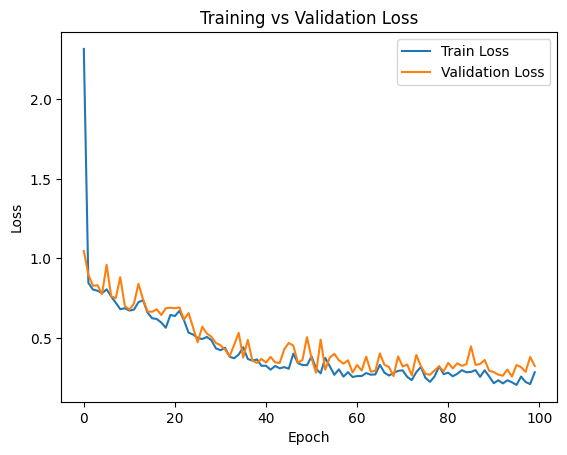

In [56]:
import matplotlib.pyplot as plt

train_losses = []
val_losses = []

for epoch in range(1, 101):
    train_loss = train()
    val_loss = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train {train_loss:.4f}, Val {val_loss:.4f}")

plt.figure()

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

## Evaluate

In [63]:
import torch.nn.functional as F

def denormalize(y, mean, std):
    return y * std + mean

@torch.no_grad()
def test_rmse():
    model.eval()

    y_true_all = []
    y_pred_all = []

    for data in test_loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)

        y_pred = denormalize(out, mean, std)
        y_true = denormalize(data.y, mean, std)

        y_true_all.append(y_true)
        y_pred_all.append(y_pred)

    y_true_all = torch.cat(y_true_all)
    y_pred_all = torch.cat(y_pred_all)

    rmse = torch.sqrt(F.mse_loss(y_pred_all, y_true_all))
    return rmse.item()

In [58]:
rmse = test_rmse()
print(f"Test RMSE: {rmse:.3f} logS")

Test RMSE: 1.133 logS


## Try out printing some log S values

In [59]:
import torch
from rdkit import Chem
import pubchempy as pcp

# SMILES to mol
def smiles_to_name(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return "Invalid SMILES"

        smiles = Chem.MolToSmiles(mol)  # canonical

        compounds = pcp.get_compounds(smiles, 'smiles')

        if compounds:
            compound = compounds[0]

            if compound.iupac_name:
                return compound.iupac_name
            elif compound.synonyms:
                return compound.synonyms[0]

    except Exception as e:
        return f"Lookup failed"

    return "Unknown"

@torch.no_grad()
def print_smiles_predictions(model, test_dataset, smiles_list, mean, std, device, num_samples=10):
    model.eval()

    num_samples = min(num_samples, len(dataset))  # safety

    for i in range(num_samples):
        data = dataset[i].to(device)

        batch = torch.zeros(data.x.size(0), dtype=torch.long).to(device)

        out = model(data.x, data.edge_index, data.edge_attr, batch)

        # Denormalize safely
        y_pred = (out * std + mean).item()
        y_true = (data.y * std + mean).item()

        smiles = smiles_list[i]
        name = smiles_to_name(smiles)

        print(f"Name: {name}")
        print(f"SMILES: {smiles_list[i]}")
        print(f"Predicted logS: {y_pred:.3f}")
        print(f"True logS:      {y_true:.3f}")
        print(f"Error:          {abs(y_pred - y_true):.3f}")
        print("-"*60)

In [60]:
print_smiles_predictions(model, test_dataset, smiles_list, mean, std, device)

Name: 2-phenyl-2-[3,4,5-trihydroxy-6-[[3,4,5-trihydroxy-6-(hydroxymethyl)oxan-2-yl]oxymethyl]oxan-2-yl]oxyacetonitrile
SMILES: OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O 
Predicted logS: -1.983
True logS:      -1.750
Error:          0.233
------------------------------------------------------------
Name: 2-methyl-N-phenylfuran-3-carboxamide
SMILES: Cc1occc1C(=O)Nc2ccccc2
Predicted logS: -3.252
True logS:      -3.800
Error:          0.548
------------------------------------------------------------
Name: 3,7-dimethylocta-2,6-dienal
SMILES: CC(C)=CCCC(C)=CC(=O)
Predicted logS: -3.223
True logS:      -3.590
Error:          0.367
------------------------------------------------------------
Name: picene
SMILES: c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
Predicted logS: -4.840
True logS:      -7.337
Error:          2.497
------------------------------------------------------------
Name: thiophene
SMILES: c1ccsc1
Predicted logS: -1.671
True logS:      -1.989
Error:          0.318
---------

In [61]:
import torch

@torch.no_grad()
def get_predictions(model, dataset, mean, std, device):
    model.eval()

    y_true_list = []
    y_pred_list = []

    for data in dataset:
        data = data.to(device)

        batch = torch.zeros(data.x.size(0), dtype=torch.long).to(device)
        out = model(data.x, data.edge_index, data.edge_attr, batch)

        # Denormalize
        y_pred = (out * std + mean).item()
        y_true = (data.y * std + mean).item()

        y_true_list.append(y_true)
        y_pred_list.append(y_pred)

    return y_true_list, y_pred_list

RMSE: 1.133
R²:   0.717


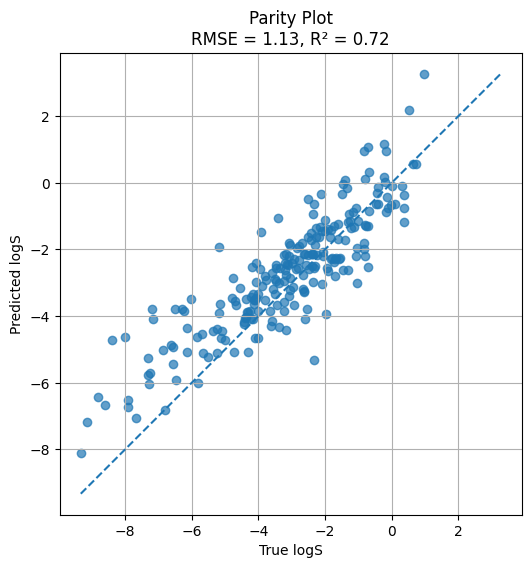

In [72]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

y_true, y_pred = get_predictions(model, test_dataset, mean, std, device)

# Convert to numpy
y_true = np.array(y_true)
y_pred = np.array(y_pred)


mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)   # compatible with all sklearn versions
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")


plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.7)

# Correct diagonal line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("True logS")
plt.ylabel("Predicted logS")
plt.title(f"Parity Plot\nRMSE = {rmse:.2f}, R² = {r2:.2f}")
plt.grid()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()